In [16]:
%load_ext autoreload
%autoreload 2

# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../")) 


import yaml
import pickle
from tqdm import tqdm

import numpy as np
import pandas as pd

import seaborn as sns
palette = sns.color_palette("Paired", 6)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions, knowledge_functions
from counterfactual_alignment import utilities as ut

from counterfactual_alignment.pipeline import Pipeline


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
"""
Gen Datasets
"""

"""
Initialise Parameters
"""

config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)

def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])


size = config['data_params']['train_size'] + config['data_params']['validation_size']

X_dims = 2
X = np.array([(x,x**2) for x in np.linspace(-5,5,size)]) + jax.random.normal(noise_key,(size,X_dims))*0.5 # multiply by scaling factor

Y = np.zeros_like(X[:,0])
Y[int(size/2 + size%2):] = 1

y_preds = optimum_classifier(X)

sample_indices = np.empty(0)
# sample training set
for i,_ in enumerate(list(set(Y))):
      sample_indices = np.concatenate((sample_indices,jax.random.randint(sample_key,tuple([int(config['data_params']['train_size']/2)]),np.ceil(i*size/2),np.floor((i+1)*size/2))))

# sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 


In [18]:

X_train_CE = np.array([X[int(i)] for i in sample_indices])
Y_train_CE = np.array([Y[int(i)] for i in sample_indices])


X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train_CE[:,0],
                         'x_1':X_train_CE[:,1],
                         'Class':Y_train_CE})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})



### Add path of points between observation and counterfactual

In [19]:
n_samples = 3


knowledge = knowledge_functions.counterfactual_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)

K_X = knowledge['origin'].reshape(int(n_samples*config['data_params']['train_size']),X_dims)
K_Y = np.array([[y]*n_samples for y in Y_train_CE]).reshape(int(n_samples*config['data_params']['train_size']))

K_df = pd.DataFrame({'x_0':K_X[:,0],
                      'x_1':K_X[:,1],
                      'Class':K_Y})

Generating 3 counterfactual samples per observation ...


20it [00:00, 843.92it/s]


### Visualise

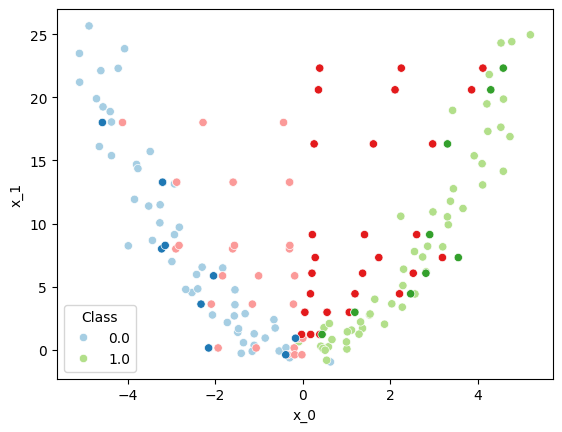

In [20]:

if config['visualisation']['visualise']:
#     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
    test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
    K_scatter = sns.scatterplot(data=K_df,x='x_0',y='x_1',hue='Class',palette=[palette[4],palette[5]],legend=False)
    train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)
    

### Method 1
baseline

Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_20__LOSS_loss_wrapper__ALPHA_1.0__METHOD_baseline


 40%|████      | 4/10 [00:00<00:00,  6.69it/s]

Train Loss: 0.6801665425300598, Train Accuracy: 60.000003814697266
Validation Loss: 0.7098948359489441, Validation Accuracy: 55.88235092163086
Train Loss: 0.678585946559906, Train Accuracy: 60.000003814697266
Validation Loss: 0.7164634466171265, Validation Accuracy: 56.86274719238281
Train Loss: 0.6461097598075867, Train Accuracy: 60.000003814697266
Validation Loss: 0.6826667189598083, Validation Accuracy: 56.86274719238281
Train Loss: 0.5921526551246643, Train Accuracy: 60.000003814697266
Validation Loss: 0.6314617395401001, Validation Accuracy: 60.78431701660156
Train Loss: 0.5250334143638611, Train Accuracy: 65.0
Validation Loss: 0.56878662109375, Validation Accuracy: 66.66667175292969


100%|██████████| 10/10 [00:01<00:00,  9.91it/s]

Train Loss: 0.4601764380931854, Train Accuracy: 75.0
Validation Loss: 0.5042557120323181, Validation Accuracy: 71.56863403320312
Train Loss: 0.32489290833473206, Train Accuracy: 95.0
Validation Loss: 0.3684720993041992, Validation Accuracy: 89.21569061279297
Train Loss: 0.23800639808177948, Train Accuracy: 100.0
Validation Loss: 0.26291537284851074, Validation Accuracy: 98.03922271728516
Train Loss: 0.185550257563591, Train Accuracy: 100.0
Validation Loss: 0.20375728607177734, Validation Accuracy: 98.03922271728516
Train Loss: 0.14388422667980194, Train Accuracy: 100.0
Validation Loss: 0.16321749985218048, Validation Accuracy: 98.03922271728516
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_20__LOSS_loss_wrapper__ALPHA_1.0__METHOD_baseline. Trained for 10 epochs.


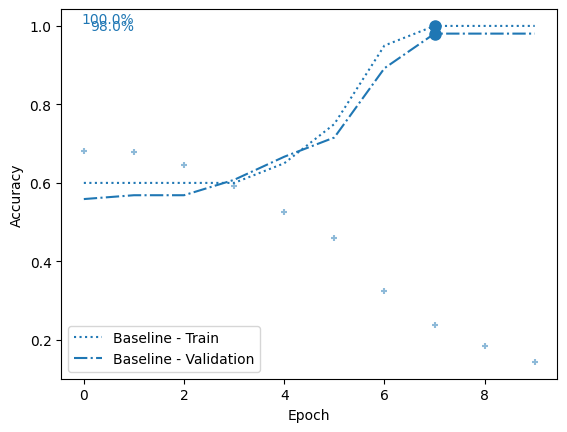

In [23]:
# config['hyperparams']['loss_function'] = 'cross_entropy'


datasets = {'train' :data.TensorDataset(torch.tensor(X_train_CE),torch.tensor(Y_train_CE),torch.tensor(np.zeros_like(X_train_CE))),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}

pipeline = Pipeline(datasets,data_description="",method_description="baseline",overwrite=True)

pipeline.run()
baseline_name = pipeline.output_name

res = []
for output_name in [pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])



### Method 2
Add counterfactual directions and learn using a combination of cross-entropy and these counterfactuals. Do not use the X data from counterfactuals for learning from cross-entropy

In [7]:
k_dim = np.shape(knowledge['origin'])

K_vector = np.vstack([
    knowledge['vector'][i] for i in range(k_dim[0]) for _ in range(k_dim[1])
])

In [8]:
#Adding K to X
K_train_D = np.zeros_like(X_train_CE)
K_train_D = np.concatenate((K_train_D,K_vector))
X_train_D = np.concatenate((X_train_CE,K_X))
Y_train_D = np.concatenate((Y_train_CE,K_Y))


Test with loss mix zero to ensure same as cross entropy

{'data_params': {'boundary_only': False, 'dataset': 'XOR', 'knowledge_func': 'counterfactual', 'max_delta': 1.0, 'n_vec': 1, 'train_size': 20, 'validation_size': 100}, 'hyperparams': {'batch_size': 8, 'epochs': 50, 'learning_rate': 0.05, 'loss_function': 'direction_new', 'loss_mix': 0.0, 'model': 'simple', 'model_io': (8, 1), 'model_size': (80, 1), 'momentum': 0.5, 'seed': 100}, 'visualisation': {'draw_eval': True, 'plot_epoch': False, 'video': False, 'visualise': True}}
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_80__LOSS_direction_new__ALPHA_0.0__METHOD_baseline


  0%|          | 0/10 [00:00<?, ?it/s]

CE_LOSS: 0.7181689143180847
ALPHA 0.0
CE_LOSS: nan
ALPHA 0.0
CE_LOSS: 0.2702198326587677
ALPHA 0.0
CE_LOSS: 0.581017017364502
ALPHA 0.0
CE_LOSS: nan
ALPHA 0.0
CE_LOSS: 0.40793558955192566
ALPHA 0.0
CE_LOSS: 0.2874559760093689
ALPHA 0.0
CE_LOSS: 1.1407315731048584
ALPHA 0.0
CE_LOSS: 0.6476006507873535
ALPHA 0.0
CE_LOSS: 1.2457764148712158
ALPHA 0.0


 10%|█         | 1/10 [00:03<00:35,  3.90s/it]

Train Loss: 1.0458102226257324, Train Accuracy: 55.0
Validation Loss: 1.1224699020385742, Validation Accuracy: 52.94117736816406
CE_LOSS: 0.576667070388794
ALPHA 0.0
CE_LOSS: 0.5893937349319458
ALPHA 0.0
CE_LOSS: 2.52201247215271
ALPHA 0.0
CE_LOSS: 1.0712522268295288
ALPHA 0.0
CE_LOSS: 1.447456955909729
ALPHA 0.0
CE_LOSS: nan
ALPHA 0.0


...

CE_LOSS: 0.30442920327186584
ALPHA 0.0
CE_LOSS: 0.7392803430557251
ALPHA 0.0
CE_LOSS: 0.21542201936244965
ALPHA 0.0
Train Loss: 0.37437957525253296, Train Accuracy: 90.0
Validation Loss: 0.30657458305358887, Validation Accuracy: 99.01960754394531
CE_LOSS: nan
ALPHA 0.0
CE_LOSS: 0.1825307160615921
ALPHA 0.0
CE_LOSS: 0.6347643136978149
ALPHA 0.0
CE_LOSS: 0.3033103942871094
ALPHA 0.0


 90%|█████████ | 9/10 [00:07<00:00,  2.25it/s]

CE_LOSS: 0.1846400946378708
ALPHA 0.0
CE_LOSS: 0.06246272847056389
ALPHA 0.0
CE_LOSS: 0.274517297744751
ALPHA 0.0
CE_LOSS: nan
ALPHA 0.0
CE_LOSS: 0.2725217938423157
ALPHA 0.0
CE_LOSS: 0.06892634183168411
ALPHA 0.0
Train Loss: 0.29714399576187134, Train Accuracy: 96.25
Validation Loss: 0.22431717813014984, Validation Accuracy: 98.03922271728516
CE_LOSS: 0.03569870442152023
ALPHA 0.0
CE_LOSS: 0.07620280981063843
ALPHA 0.0
CE_LOSS: 0.15491242706775665
ALPHA 0.0
CE_LOSS: 0.10697232186794281
ALPHA 0.0
CE_LOSS: 0.6427904963493347
ALPHA 0.0
CE_LOSS: 0.33352288603782654
ALPHA 0.0
CE_LOSS: 0.07035728543996811
ALPHA 0.0
CE_LOSS: 0.3995482921600342
ALPHA 0.0


100%|██████████| 10/10 [00:07<00:00,  1.26it/s]

CE_LOSS: 0.23917631804943085
ALPHA 0.0
CE_LOSS: 0.08875612914562225
ALPHA 0.0
Train Loss: 0.23053978383541107, Train Accuracy: 96.25
Validation Loss: 0.1517745554447174, Validation Accuracy: 98.03922271728516
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_80__LOSS_direction_new__ALPHA_0.0__METHOD_baseline. Trained for 10 epochs.


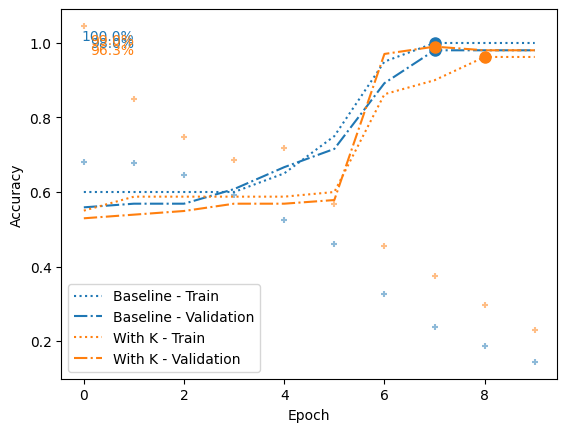

In [9]:
config['hyperparams']['loss_function'] = 'direction_new'
config['hyperparams']['loss_mix'] = 0.0
method_description = "add_K_to_X"




datasets = {'train' :data.TensorDataset(torch.tensor(X_train_D),torch.tensor(Y_train_D),torch.tensor(K_train_D)),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}

pipeline = Pipeline(datasets,config=config,data_description="",method_description="baseline",overwrite=True)

pipeline.run()

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])



now upping alpha

{'data_params': {'boundary_only': False, 'dataset': 'XOR', 'knowledge_func': 'counterfactual', 'max_delta': 1.0, 'n_vec': 1, 'train_size': 20, 'validation_size': 100}, 'hyperparams': {'batch_size': 8, 'epochs': 50, 'learning_rate': 0.05, 'loss_function': 'direction_new', 'loss_mix': 1.0, 'model': 'simple', 'model_io': (8, 1), 'model_size': (80, 1), 'momentum': 0.5, 'seed': 100}, 'visualisation': {'draw_eval': True, 'plot_epoch': False, 'video': False, 'visualise': True}}
Loading and saving to: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_80__LOSS_direction_new__ALPHA_1.0__METHOD_baseline


  0%|          | 0/10 [00:00<?, ?it/s]

CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: nan
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: nan
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0


 10%|█         | 1/10 [00:00<00:02,  3.21it/s]

CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
Train Loss: 0.7553735971450806, Train Accuracy: 55.0
Validation Loss: 0.8167375326156616, Validation Accuracy: 52.94117736816406
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0


...

CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
Train Loss: 0.7553735971450806, Train Accuracy: 55.0
Validation Loss: 0.8167375326156616, Validation Accuracy: 52.94117736816406
CE_LOSS: nan
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: nan
ALPHA 1.0


 90%|█████████ | 9/10 [00:02<00:00,  3.05it/s]

CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
Train Loss: 0.7553735971450806, Train Accuracy: 55.0
Validation Loss: 0.8167375326156616, Validation Accuracy: 52.94117736816406
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0


100%|██████████| 10/10 [00:03<00:00,  3.13it/s]

CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
CE_LOSS: 0.0
ALPHA 1.0
Train Loss: 0.7553735971450806, Train Accuracy: 55.0
Validation Loss: 0.8167375326156616, Validation Accuracy: 52.94117736816406
Model saved to /outputs as: MODEL_simple__OPTIM_adam__LR_0.05__BATCHSIZE_8__DATA___SIZE_80__LOSS_direction_new__ALPHA_1.0__METHOD_baseline. Trained for 10 epochs.


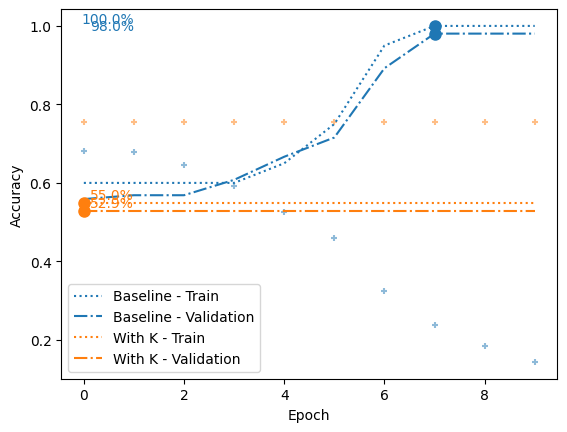

In [10]:
config['hyperparams']['loss_function'] = 'direction_new'
config['hyperparams']['loss_mix'] = 1.0
method_description = "add_K_to_X"


datasets = {'train' :data.TensorDataset(torch.tensor(X_train_D),torch.tensor(Y_train_D),torch.tensor(K_train_D)),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}

pipeline = Pipeline(datasets,config = config,data_description="",method_description="baseline",overwrite=True)

pipeline.run()

res = []
for output_name in [baseline_name,pipeline.output_name]:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])



In [11]:
config['hyperparams']['loss_function'] = 'cross_entropy'


with open(config_file, 'w') as file:
    yaml.dump(config, file)


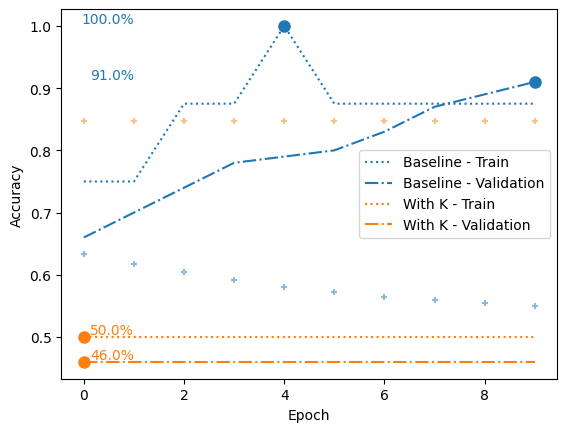

In [12]:
names= ["MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA___SIZE_8__LOSS_direction_new__ALPHA_1.0__SIZE_2__METHOD_add_K_to_X"]

res = []
for output_name in names:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

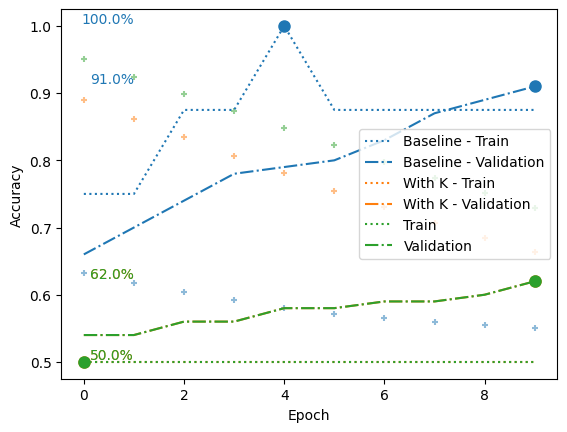

In [13]:
names= ["MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline_with_K",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_2__LOSS_cross_entropy_alpha_2__SIZE_2__METHOD_baseline",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_direction_new_alpha_2__SIZE_2__METHOD_add_K_to_X_loss_mix"]

res = []
for output_name in names:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['Baseline',"With K"])

In [14]:

"""
Load tunable parameters from config file 
"""
config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)



with open(config_file, 'w') as file:
    yaml.dump(config, file)

In [15]:
method_description = f"add_K_to_X_loss_mix_{config['hyperparams']['loss_mix']}"

pipeline(datasets,data_description="",method_description=method_description,overwrite=True)


TypeError: 'Pipeline' object is not callable

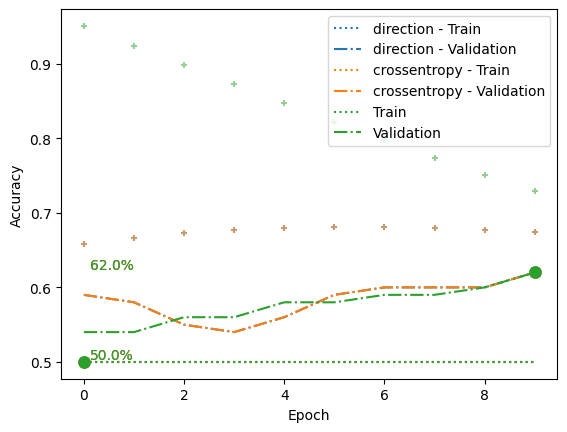

In [ ]:
names= ["MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_direction_new_alpha_2__SIZE_2__METHOD_add_K_to_X_loss_mix_1.0",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_direction_new_alpha_2__SIZE_2__METHOD_add_K_to_X_loss_mix_0.0",
        "MODEL_simple__OPTIM_adam__LR_0.01__BATCHSIZE_8__DATA__SIZE_8__LOSS_direction_new_alpha_2__SIZE_2__METHOD_add_K_to_X_loss_mix_0.5"]

res = []
for output_name in names:
        with open(os.path.join('outputs',output_name+'.pkl'), 'rb') as file: ## remove this line to load model
                res.append(pickle.load(file))


res_fig=ut.plot_from_results_file([r['results'] for r in res],loss=True, labels=['direction',"crossentropy"])